In [1]:
import pandas as pd

from lib.h_ensemble import build_ensemble_csv
from lib.plots import plot_uncertainty_distributions
from lib.utils import compute_uncertainties
import numpy as np
# load data 
""" MAIN SETTINGS AND DATA LOADING"""

dataset = 'adni'
analysis_name = 'mci_ad_conversion'
outcome_name = 'label_bl_36m'
build_ensemble_csv(analysis_name, outcome_name, index_col=['subject_id','month'])


all_patients = pd.read_csv(f'../data/{dataset}/adni_baseline_only_36m.csv')



# load all predictions for the full training set (including active patients at bl)
patients_stats = pd.read_csv(f'../results/classification/{analysis_name}/{outcome_name}/aggregated/patient_mean_probs_{outcome_name}_{analysis_name}_model.csv')
patients_stats.set_index(['subject_id', 'month'], inplace=True)



# 1. Extract the inner list from each row using .str[0]
import ast

# 1. Convert the string representation "[0.8, 0.83...]" into a real Python list
real_lists = patients_stats['all_probs'].apply(ast.literal_eval)

# 2. Now expand those lists into columns
probs_raw_df = pd.DataFrame(real_lists.tolist(), index=patients_stats.index)


all_patients.set_index(['subject_id', 'month'], inplace=True)

Successfully aggregated 9450 predictions across 314 unique patients.


## Uncertainty Decomposition

Baseline entropy: 0.9950485853501994


/storage/DSH/projects/neuroart/uncertainty_ml/code_rejection_analysis/lib/plots.py:83: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


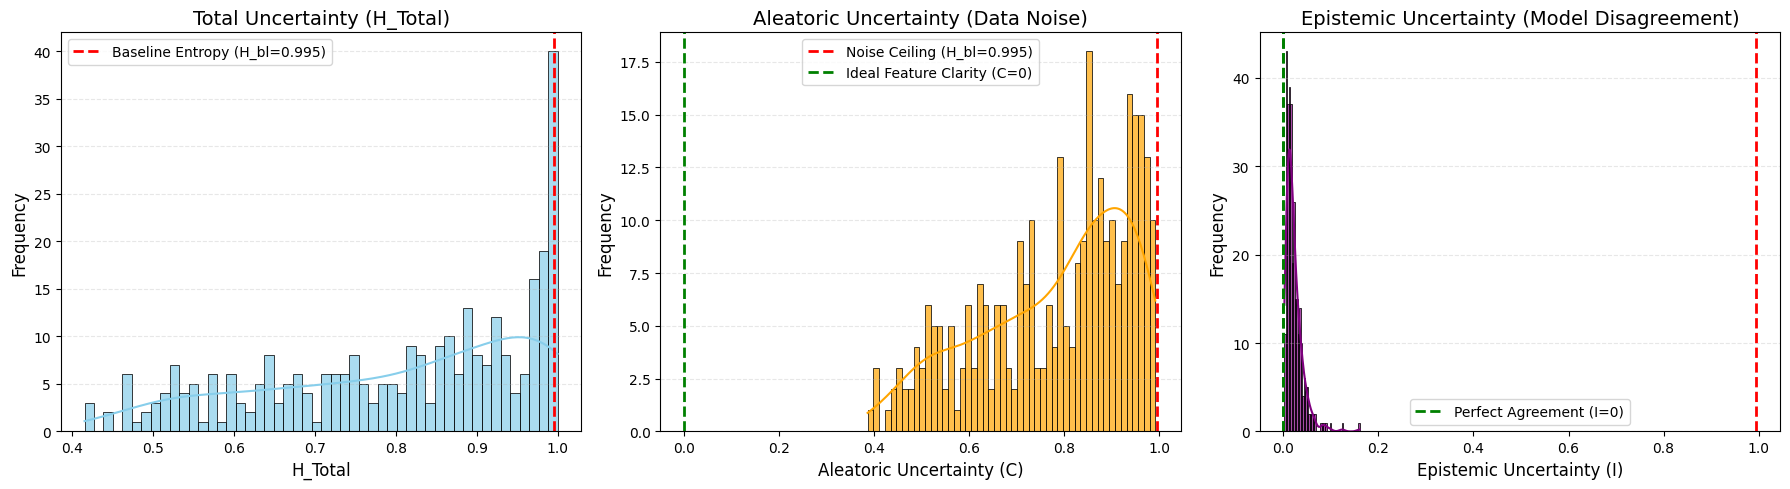

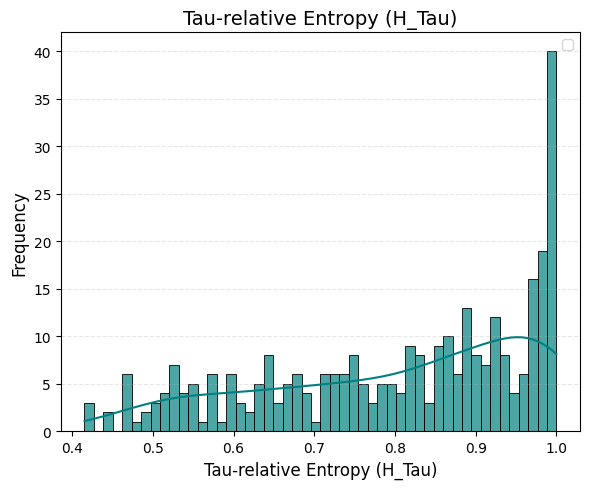

In [2]:
# Compute uncertainties for the non-active patients at baseline


uncertainty_results = compute_uncertainties(probs_raw_df)

# Create an explicit copy to avoid SettingWithCopyWarning
patients_stats_copy = patients_stats.copy()

# 2. Add the results to your main stats table
patients_stats_copy['H_Total'] = uncertainty_results['H_Total']
patients_stats_copy['C_Aleatoric'] = uncertainty_results['C_Aleatoric']
patients_stats_copy['I_Epistemic'] = uncertainty_results['I_Epistemic']
patients_stats_copy['Distance_to_Tau'] = uncertainty_results['Distance_to_Tau']
patients_stats_copy['MW_H_Total'] = uncertainty_results['MW_H_Total']
patients_stats_copy['H_Tau'] = uncertainty_results['H_Tau']

# Compute the baseline risk (mean of probs_cal across all folds) for each patient and its uncertainty value 
proportion_positive = all_patients['label'].sum() / len(all_patients)
H_bl = -(proportion_positive * np.log2(proportion_positive + 1e-12) +
         (1 - proportion_positive) * np.log2(1 - proportion_positive + 1e-12))
print("Baseline entropy:", H_bl)



plot_uncertainty_distributions(
     patients_stats_copy, 
     H_bl, 
     #save_path='../results/uncertainty/plots/uncertainty_distributions.png'
 )

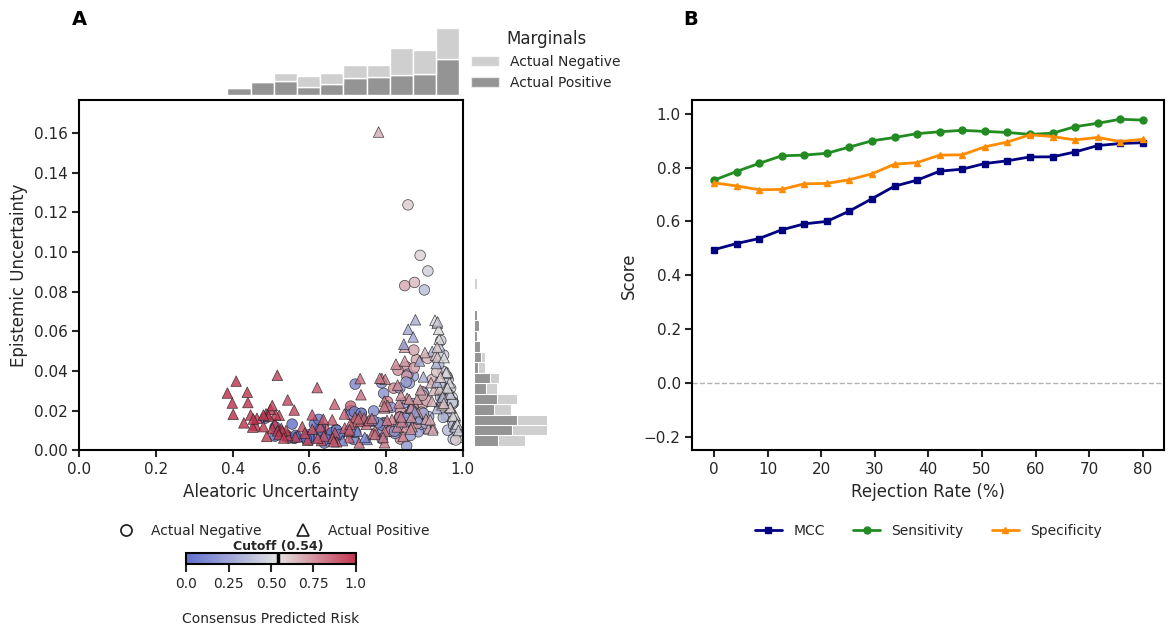

In [3]:
from lib.plots import plot_combined_uncertainty_analysis_v2


plot_combined_uncertainty_analysis_v2(patients_stats_copy, uncertainty_type='H_Tau', y_true=all_patients['label'])

## Explore clinical data through GMM analysis
No clear separation between patients. The two scores do not agree on the number of clusters. For this dataset we are going to skip the GMM analysis and rejection and move on to Conditioned Classification Rejection Curves (CCRC).

Number of original clinical features: 11
Optimal PCs according to the Kaiser Rule: 4

Top 5 Eigenvalues:
[2.33 1.48 1.2  1.1  0.96]


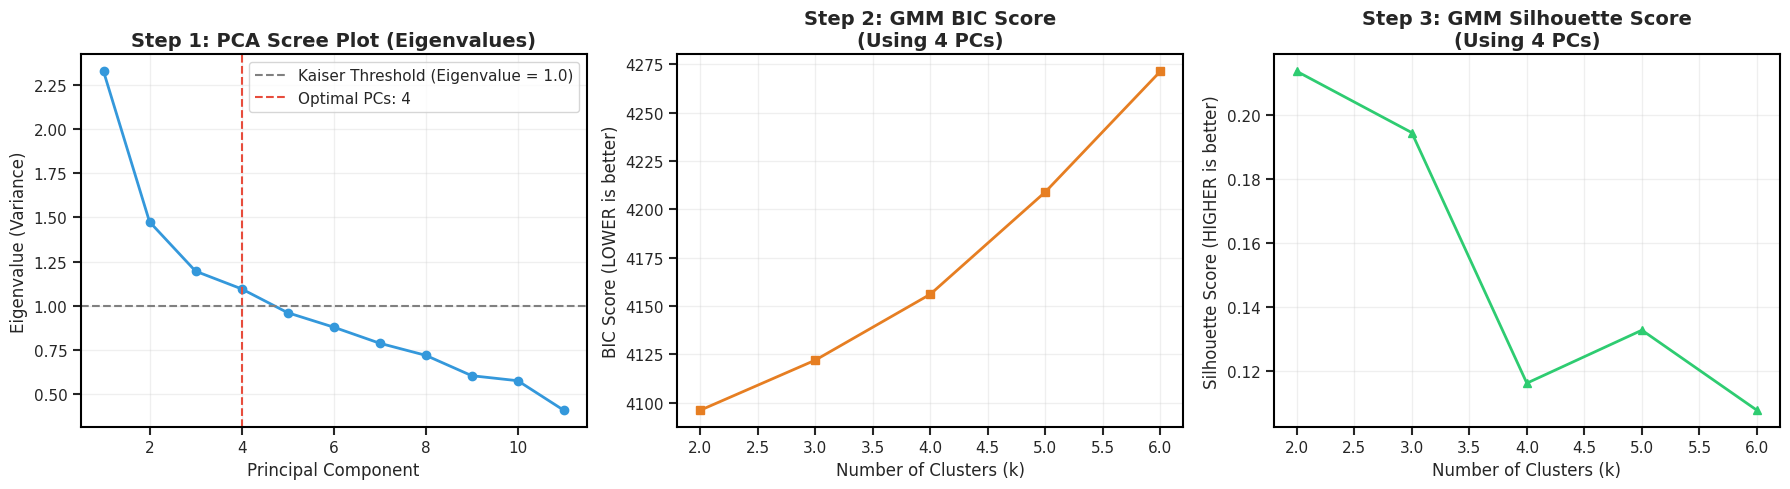


--- Optimization Results ---
1. Optimal PCs retained (Kaiser Rule, Eigenvalue > 1.0): 4
2. Best GMM model according to BIC (lowest complexity penalty): k = 2
3. Best GMM model according to Silhouette (highest separation): k = 2


In [21]:
from lib.clustering import optimize_pca_and_gmm_kaiser


optimize_pca_and_gmm_kaiser(X_clinical = all_patients.drop(['label'], axis=1), max_clusters=6)

In [22]:
""" Run gmm clustering and analyze the two clusters"""
X_clinical = all_patients.drop(['label'], axis=1)
# 1. Prepare Data
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.mixture import GaussianMixture

from lib.clustering import profile_clinical_clusters


imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X_clinical)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

pca_opt = PCA(n_components=9, random_state=42)
X_pca = pca_opt.fit_transform(X_scaled)

final_gmm = GaussianMixture(n_components=2, random_state=42, n_init=10)
clusters = final_gmm.fit_predict(X_pca)

cluster_probs = final_gmm.predict_proba(X_pca)

phenotype_labels = np.where(clusters == 0, 'Phenotype A (Predictable - advanced)', 'Phenotype B (Invisible - mild)')

patients_stats_copy['Phenotype'] = phenotype_labels

clinical_profile = profile_clinical_clusters(X_clinical, patients_stats_copy)

--- Clinical Signature of the Phenotypes ---
    Clinical_Feature  Mean_Phenotype_A  Mean_Phenotype_B P_Value
            PTGENDER              1.00              0.00  <0.001
        age_at_visit             72.91             75.34  0.0088
            PTEDUCAT             15.21             15.97  0.0406
             MMSCORE             26.84             27.20  0.0894
months_to_conversion             11.60              9.09  0.1176
            FAQTOTAL              3.44              4.14  0.2971
             TOTAL13             18.94             18.42  0.3508
            NPISCORE              1.67              2.02  0.5484
                MOCA             24.52             24.70  0.6525
               CDRSB              1.60              1.63  0.7688


## Conditioned Classification Rejection Curves (CCRC)

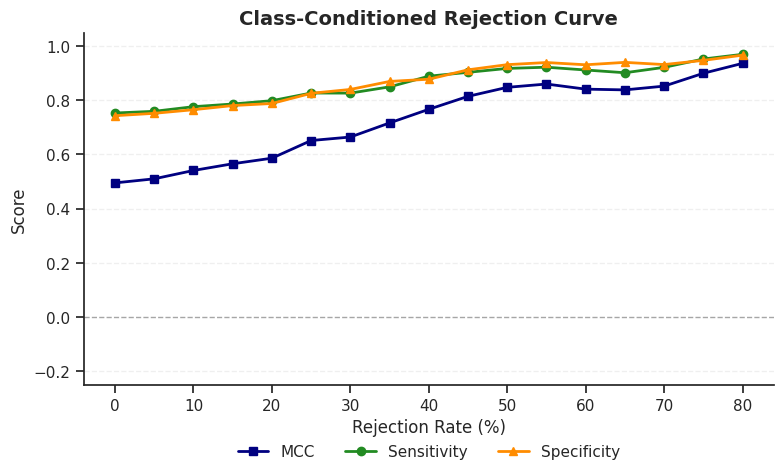

GLOBAL CLASS-CONDITIONED REJECTION: METRICS EVOLUTION
 Rejection (%)  Total Kept  TP  FP  TN  FN   MCC  Sensitivity  Specificity
             0         314 128  37 107  42 0.495        0.753        0.743
             5         299 123  34 103  39 0.510        0.759        0.752
            10         284 118  31 101  34 0.541        0.776        0.765
            15         268 114  27  96  31 0.566        0.786        0.780
            20         252 107  25  93  27 0.586        0.799        0.788
            25         236 105  19  90  22 0.651        0.827        0.826
            30         221 100  16  84  21 0.664        0.826        0.840
            35         205  96  12  80  17 0.716        0.850        0.870
            40         189  88  11  79  11 0.767        0.889        0.878
            45         173  84   7  73   9 0.815        0.903        0.912
            50         158  78   5  68   7 0.848        0.918        0.932
            55         143  71   4  62   6 0.8

In [5]:
from lib.plots import plot_class_conditioned_rejection_curve


optimal_threshold = all_patients['label'].mean()

class_cond_results = plot_class_conditioned_rejection_curve(
    patients_stats_copy, 
    threshold=optimal_threshold, 
    uncertainty_col='H_Total',
    rates=np.linspace(0, 80, 17)
)

### Confusion matrix evolution analysis


Standard global rejection frameworks fail in clinical datasets because predicting the onset of a future disease (Class 1) is inherently noisier than diagnosing baseline stability (Class 0). This Asymmetric Aleatoric Uncertainty causes standard algorithms to disproportionately delete the positive class, crashing the Sensitivity to zero.

By implementing Class-Conditioned Rejection tied to the baseline prior, we successfully decoupled the rejection threshold from this asymmetric noise.

Dataset 1 (The Imbalanced Cohort | Prior ~0.11) -> The "Rescue" Mechanism

Observation: The baseline model struggles with the rare minority class (Sens: ~0.69, MCC: 0.27).

Impact: Class-Conditioned Rejection actively rescues the model. By dropping the top 25% of uncertain patients proportionally from both predicted classes, Sensitivity actually rises to ~0.76 and holds steady. We successfully deferred a quarter of the most ambiguous patients without artificially collapsing the rare disease class.

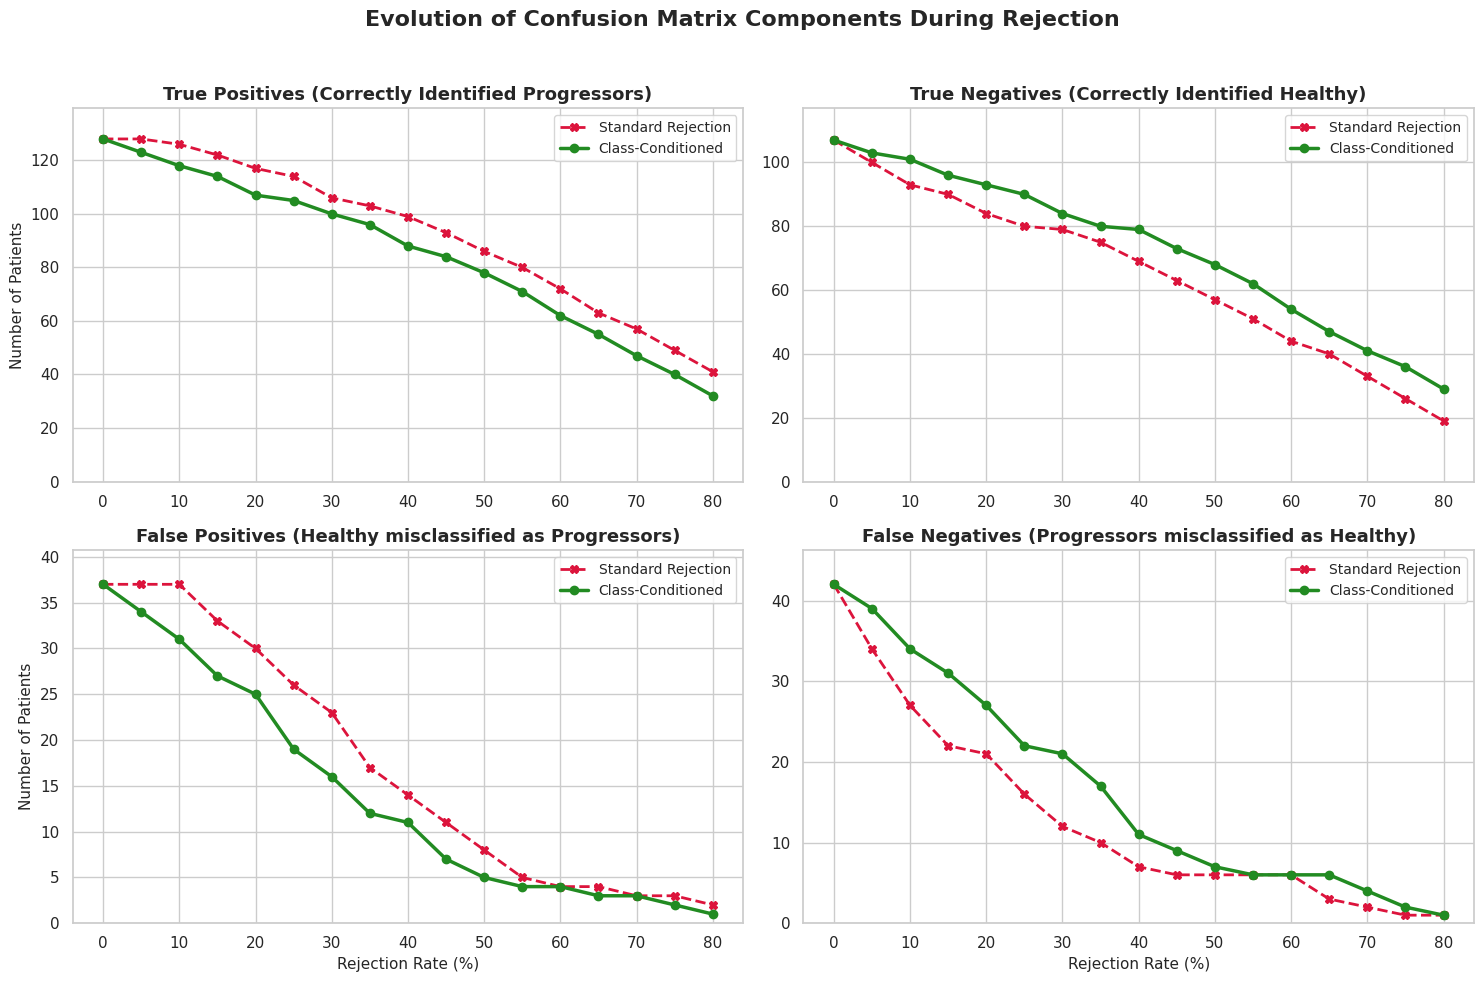

In [7]:
from lib.plots import plot_comprehensive_rejection_dashboard


optimal_threshold = patients_stats_copy['label'].mean()
dashboard_results = plot_comprehensive_rejection_dashboard(patients_stats_copy, uncertainty_col='H_Tau', threshold=optimal_threshold)

In [8]:

from lib.utils import extract_and_analyze_rejection


optimal_threshold = patients_stats_copy['label'].mean()

# Extract the patients at a 25% rejection rate
kept_df, removed_df, uncertainty_stats = extract_and_analyze_rejection(
     patients_stats_copy, 
     prior_threshold=optimal_threshold, 
     rate=25, 
     method='class_conditioned',
     sort_col='H_Tau',
     uncertainty_cols=['H_Total', 'C_Aleatoric', 'I_Epistemic', 'sigma']
)

REJECTION AUDIT: CLASS_CONDITIONED @ 25%
Total Cohort:    314 patients
Total Kept:      236 patients
Total Removed:   78 patients
--------------------------------------------------------------------------------
UNCERTAINTY PROFILE COMPARISON:
     Metric  Kept_Profile Removed_Profile P_Value
    H_Total 0.747 ± 0.151   0.979 ± 0.024  <0.001
C_Aleatoric 0.729 ± 0.146   0.942 ± 0.037  <0.001
I_Epistemic 0.018 ± 0.012   0.036 ± 0.026  <0.001
      sigma 0.064 ± 0.027   0.106 ± 0.035  <0.001


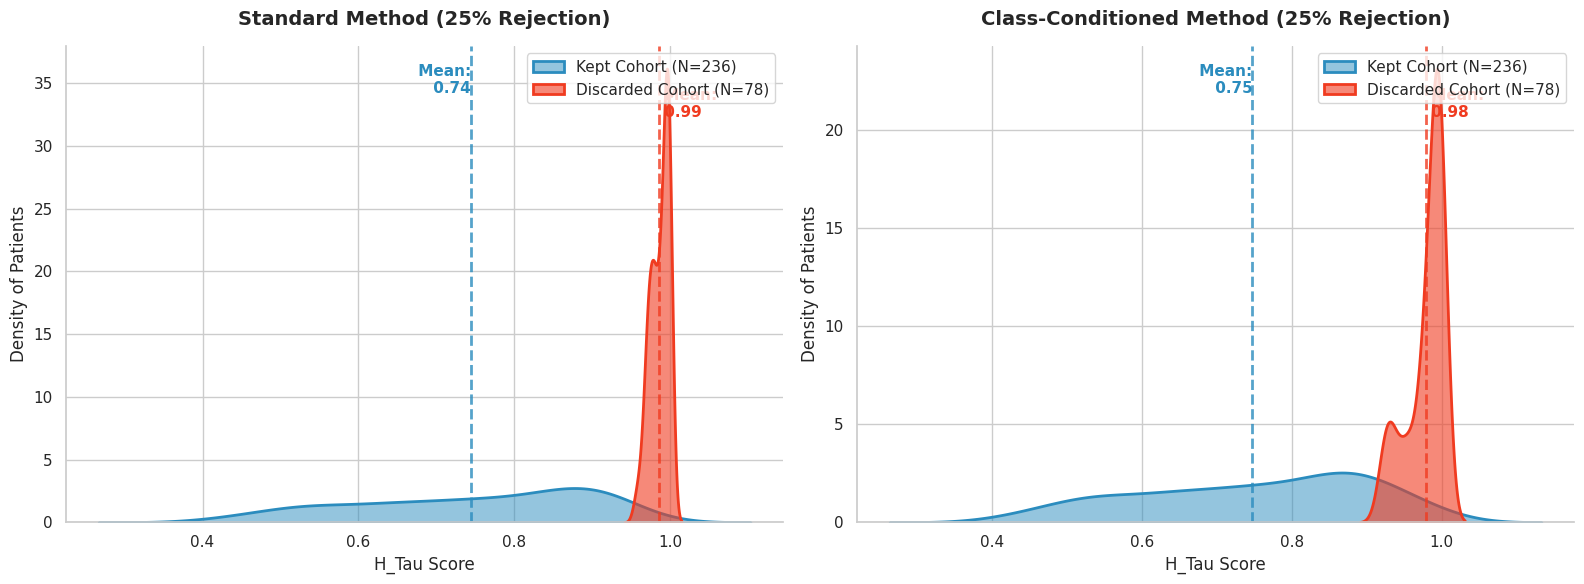

In [9]:


from lib.plots import plot_side_by_side_distributions


# --- Example Usage ---
optimal_threshold = patients_stats_copy['label'].mean()
plot_side_by_side_distributions(patients_stats_copy, uncertainty_col='H_Tau', threshold=optimal_threshold, rate=25)